#### Customer Segmentation Using K-Means
1. Business Problem
A shopping mall has information about its customers, including their age, gender, annual income, and spending score.

The marketing team wants to understand whether there are different groups of customers with different spending behaviors.

However, the company does not have predefined customer segments.

Our task is to use K-Means clustering to discover these customer segments.

In [1]:
#import libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

#### Load the data set

In [2]:
# loading the data from csv file to a Pandas DataFrame
customer_data = pd.read_csv('Mall_Customers.csv')

In [3]:
# first 5 rows in the dataframe
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# finding the number of rows and columns
customer_data.shape

(200, 5)

In [5]:
# getting some informations about the dataset
customer_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [6]:
customer_data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### Distribution of features 

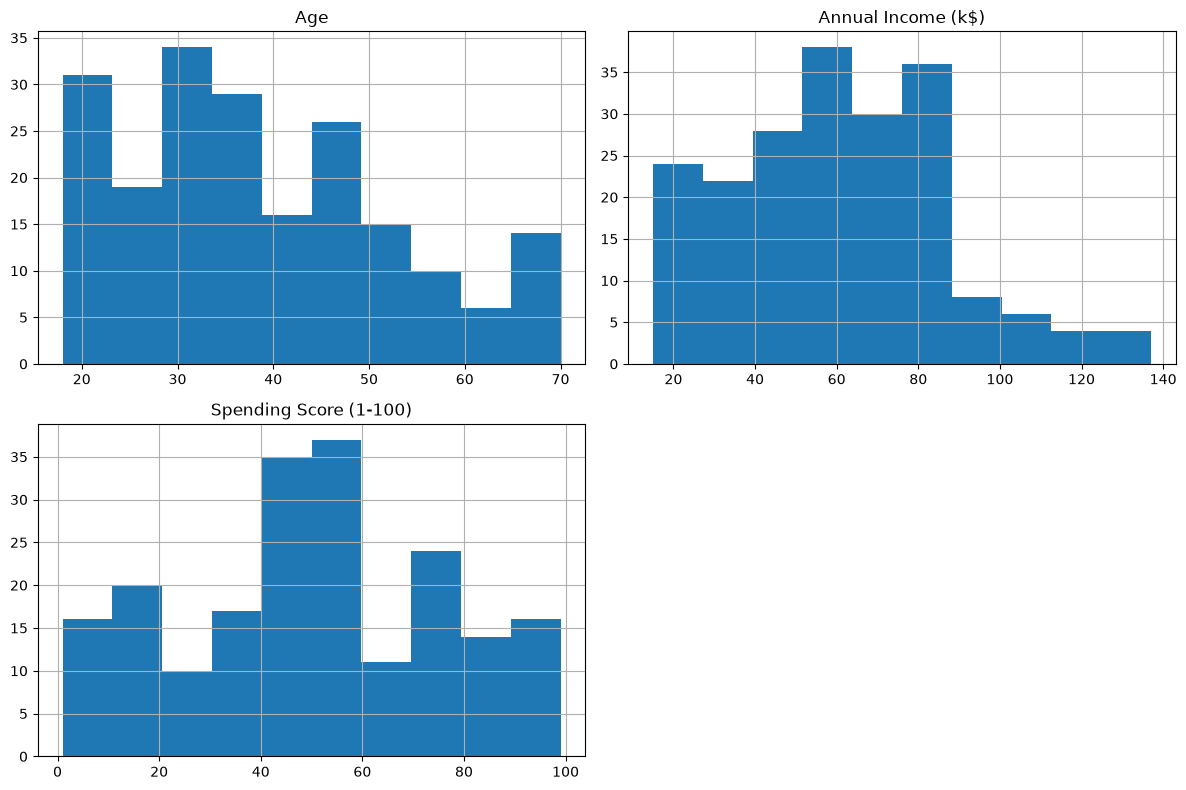

In [7]:
features = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

customer_data[features].hist(
    bins=10,
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

In [8]:
# checking for missing values
customer_data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
customer_data = customer_data.drop(columns=["CustomerID"])

#### Choosing Annual income column and spending score column

In [10]:
X = customer_data[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

In [11]:
print(X)

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


#### Visualize the Customers
##### Before applying K-Means, let's see what the data looks like.

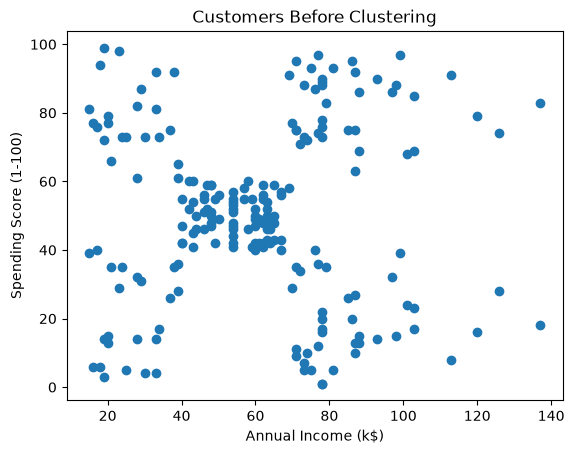

In [12]:
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customers Before Clustering")

plt.show()

We can visually see some potential groups, but we don't want to manually draw boundaries. We want a machine learning algorithm to discover those groups for us.

#### Do We Need Feature Scaling?
K-Means is distance-based, so feature scaling is generally important when features have substantially different scales.

Annual Income: approximately 15 - 137
Spending Score: 1 - 100

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Choosing the number of clusters

What is WCSS?
WCSS = Within-Cluster Sum of Squares

It measures how far observations are from the centroid of the cluster they belong to.

In simpler terms:

WCSS tells us how tightly packed our clusters are.

A smaller WCSS means observations are, on average, closer to their cluster centroids.

Imagine K = 1

If we put all customers into one cluster, we have one centroid.

Customers could be quite far from that centroid.

Therefore:

WCSS will be relatively high.

Now increase K

If we use:

K = 2

we have two centroids.

Customers can now be assigned to a centroid that is closer to them.

Therefore, WCSS decreases.

If we increase K again:

K = 3

we have three centroids, so WCSS generally decreases again.

This continues as K increases.

In [14]:
# finding wcss value for different number of clusters

wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(X)

  wcss.append(kmeans.inertia_)

init='k-means++' - controls how the initial centroids are selected.

Instead of simply choosing the starting centroids completely randomly, K-Means++ chooses initial centroids in a way that generally spreads them out more intelligently.

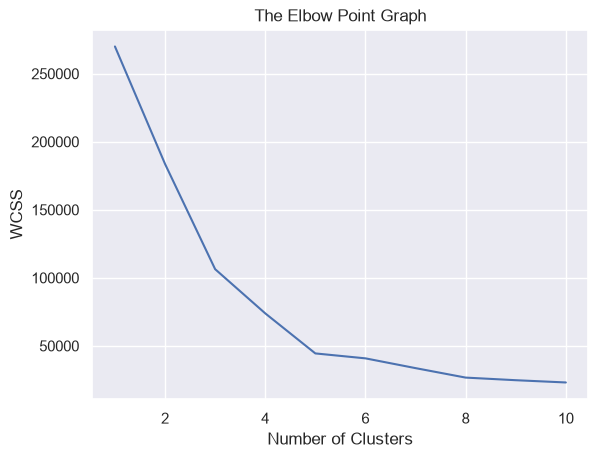

In [15]:
# plot an elbow graph

sns.set()
plt.plot(range(1,11), wcss)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

Optimum Number of Clusters = 5

Training the k-Means Clustering Model

In [16]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0)

# return a label for each data point based on their cluster
Y = kmeans.fit_predict(X)

print(Y)

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


5 Clusters - 0, 1, 2, 3, 4

The algorithm doesn't know that Cluster 0 is "high-value customers." You determine what each cluster represents by examining the characteristics of the customers in that cluster.

In [17]:
Y[0]

np.int32(3)

In [18]:
customer_data['Cluster'] = Y
customer_data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,3
1,Male,21,15,81,4
2,Female,20,16,6,3
3,Female,23,16,77,4
4,Female,31,17,40,3


Once K-Means has assigned each customer to a cluster, profiling is the step where we ask:

"What kind of customers are in each cluster?"

For customer segmentation, this is where the machine learning results become meaningful from a business perspective.

### Find the number of customers in each cluster
First, let's understand how large each segment is.

In [19]:
customer_data['Cluster'].value_counts().sort_index()

Cluster
0    81
1    39
2    35
3    23
4    22
Name: count, dtype: int64

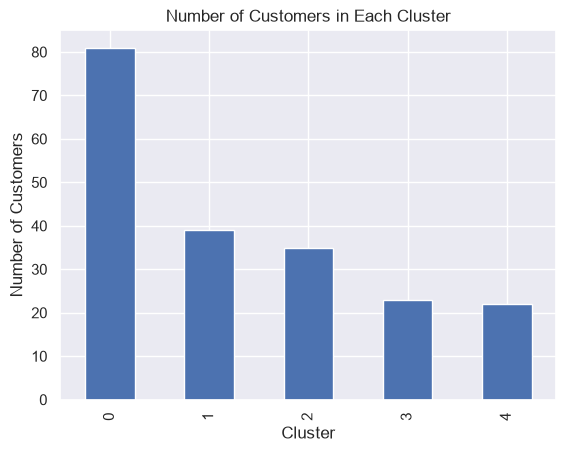

In [20]:
customer_data['Cluster'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each Cluster')
plt.show()

Calculate the average characteristics of each cluster

This is probably the most important part of profiling.

In [21]:
cluster_profile = customer_data.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean()

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,41.114286,88.200000,17.114286
3,45.217391,26.304348,20.913043
4,25.272727,25.727273,79.363636


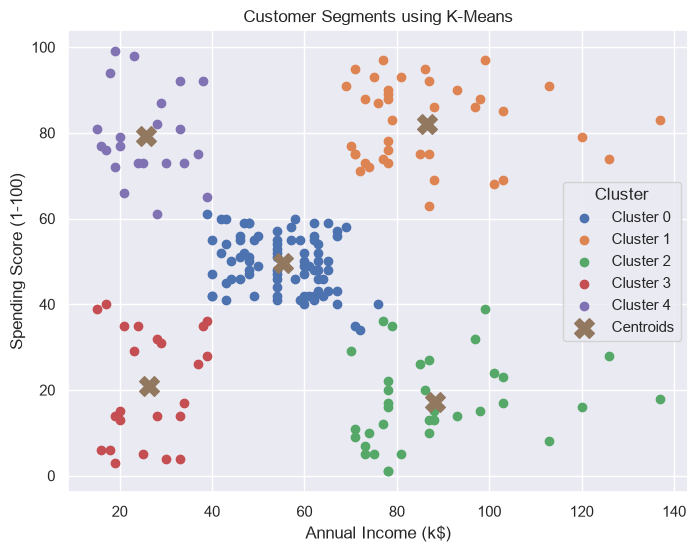

In [22]:
#Visualizing the clusters 
plt.figure(figsize=(8, 6))

# Plot each K-Means cluster
for cluster in sorted(set(Y)):
    cluster_data = X[Y == cluster]

    plt.scatter(
        cluster_data.iloc[:, 0],
        cluster_data.iloc[:, 1],
        label=f'Cluster {cluster}'
    )

# Plot K-Means centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    marker='X',
    label='Centroids'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments using K-Means')
plt.legend(title='Cluster')

plt.show()

Create the hierarchical clustering tree
For hierarchical clustering, we can use Ward's linkage:

In [34]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram

In [35]:
linkages = ['single', 'complete', 'average', 'ward']

for linkage in linkages:
    model = AgglomerativeClustering(
        n_clusters=5,
        linkage=linkage
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)

    print(f'{linkage}: {score:.3f}')

single: 0.269
complete: 0.553
average: 0.479
ward: 0.553


Single (0.269): The lowest score. It suggests that single linkage produced clusters with more overlap or chaining.

Complete (0.553): High silhouette score, indicating relatively well-separated and compact clusters.

Average (0.479): Reasonable separation, but lower than complete and Ward.

Ward (0.553): Tied with complete for the highest silhouette score.

Ward is particularly natural to consider because it is designed to create compact clusters by minimizing within-cluster variance

In [36]:
linkage_method = 'ward'

In [37]:
Z = sch.linkage(X_scaled, method=linkage_method)

#### Plot the dendrogram

This is the important visualization for hierarchical clustering.

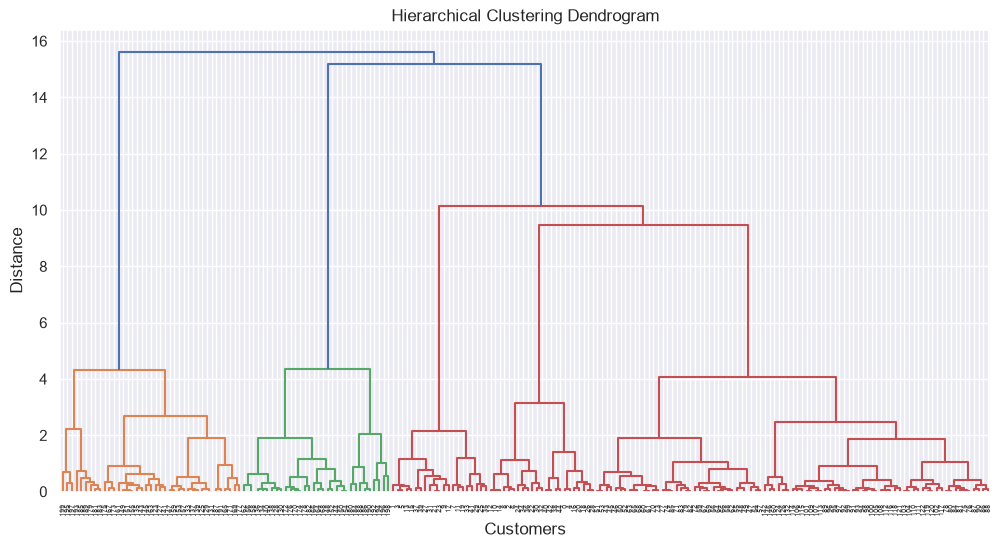

In [38]:
plt.figure(figsize=(12, 6))

dendrogram(Z)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Distance')

plt.show()

Choose the number of clusters
Suppose after examining the dendrogram, you decide to use 5 clusters.

We can then apply Agglomerative Clustering:

In [39]:
hc = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

clusters = hc.fit_predict(X_scaled)

In [40]:
customer_data['Cluster'] = clusters
customer_data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,4
1,Male,21,15,81,3
2,Female,20,16,6,4
3,Female,23,16,77,3
4,Female,31,17,40,4


Visualize the customer segments

Since we're using two features, we can easily plot them:

C:\Users\Nicole Kasiva\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


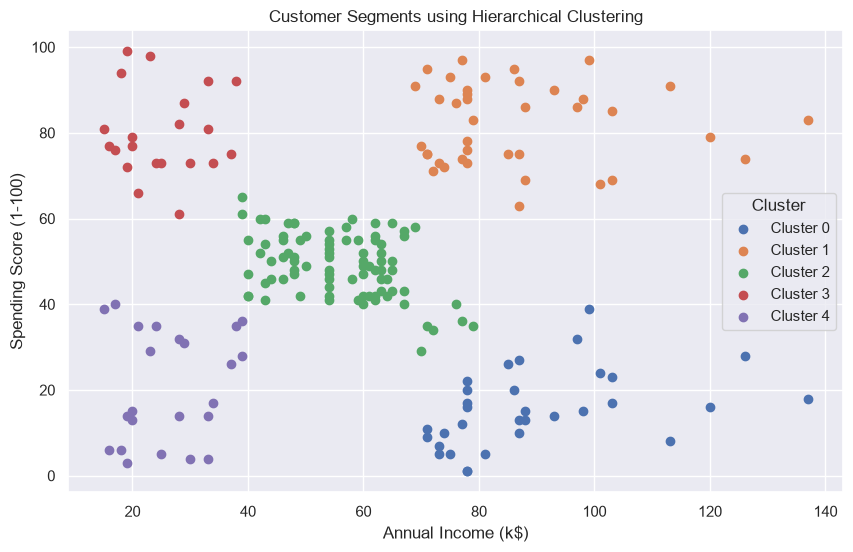

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for cluster in sorted(customer_data['Cluster'].unique()):
    cluster_data = customer_data[customer_data['Cluster'] == cluster]

    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        label=f'Cluster {cluster}'
    )

plt.title('Customer Segments using Hierarchical Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

Interpret the clusters

This is where the business meaning comes in.

In [42]:
customer_data.groupby('Cluster')[['Age',
                       'Annual Income (k$)',
                       'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,41.000000,89.406250,15.593750
1,32.692308,86.538462,82.128205
2,42.482353,55.811765,49.129412
3,25.333333,25.095238,80.047619
4,45.217391,26.304348,20.913043


DBSCAN
It works differently from hierarchical clustering: instead of deciding the number of clusters first, it identifies groups based on density and can mark unusual points as noise.

Apply DBSCAN

In [43]:
from sklearn.cluster import DBSCAN

In [44]:
dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)
clusters = dbscan.fit_predict(X_scaled)

eps defines the neighborhood around each observation.

min_samples defines how many observations need to be within that neighborhood for an area to be considered sufficiently dense.

In [45]:
customer_data['Cluster'] = clusters
customer_data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,2
1,Male,21,15,81,0
2,Female,20,16,6,1
3,Female,23,16,77,0
4,Female,31,17,40,2


In [46]:
customer_data['Cluster'].value_counts()

Cluster
 3    88
-1    35
 4    30
 5    14
 0    12
 6     9
 2     7
 1     5
Name: count, dtype: int64

Unlike hierarchical clustering, you don't tell DBSCAN "give me 5 clusters."

DBSCAN determines the clusters based on density.

-1 means that these observations were classified as noise because they did not have enough neighboring observations within the specified eps distance.

Visualize the DBSCAN clusters

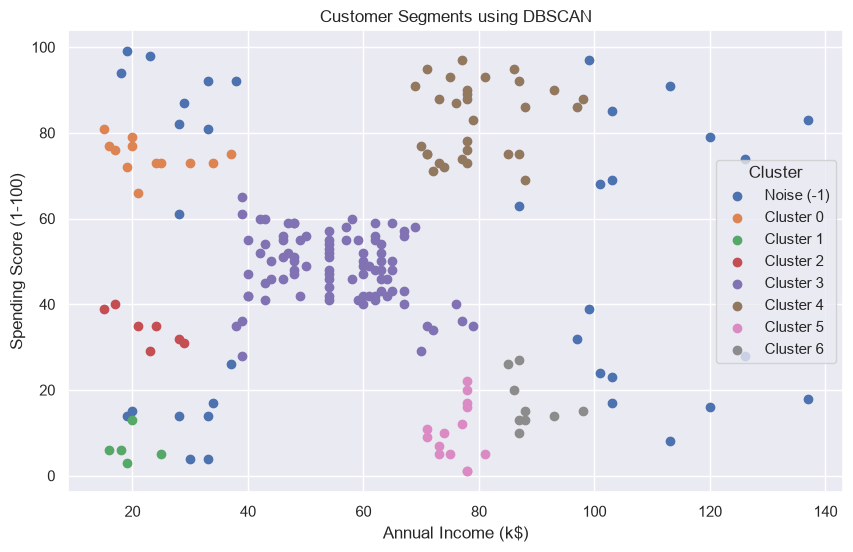

In [47]:
plt.figure(figsize=(10, 6))

for cluster in sorted(customer_data['Cluster'].unique()):
    cluster_data = customer_data[customer_data['Cluster'] == cluster]
    
    label = 'Noise (-1)' if cluster == -1 else f'Cluster {cluster}'
    
    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        label=label
    )

plt.title('Customer Segments using DBSCAN')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

How do we interpret the clusters?

Just like before, calculate the averages:

In [48]:
customer_data.groupby('Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
-1,37.685714,70.600000,51.657143
0,24.083333,23.166667,74.583333
1,40.400000,19.600000,6.600000
2,36.714286,22.428571,34.428571
3,42.875000,55.227273,48.579545
4,32.733333,79.533333,83.133333
5,37.785714,75.928571,10.071429
6,46.555556,88.777778,17.000000
